In [18]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_openai import ChatOpenAI
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver

In [19]:
class ChatState(TypedDict):

    messages: Annotated[list[BaseMessage], add_messages]      #list of BaseMessage as this list can contain Human, AI or syatem messages. 

In [20]:
llm = ChatOpenAI()

In [21]:
def Chat_node(state: ChatState):

    message = state['messages']

    response = llm.invoke(message)

    return {'messages': [response]}

In [22]:
checkpointer = MemorySaver()

graph = StateGraph(ChatState)

graph.add_node('Chat_node', Chat_node)

graph.add_edge(START, 'Chat_node')
graph.add_edge('Chat_node', END)

ChatBot = graph.compile(checkpointer= checkpointer)

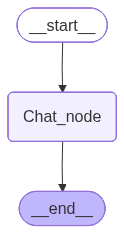

In [23]:
ChatBot

In [25]:
thread_id = '1'

while True:

    user_message = input('Type here: ')
    print('User:', user_message)

    if user_message.strip().lower() in ['exit', 'quit', 'bye']:
        break

    config = {'configurable': {'thread_id': thread_id}}
    response = ChatBot.invoke({'messages': [HumanMessage(content= user_message)]}, config= config )
    print('AI:', response['messages'][-1].content)

User: Hi
AI: Hello! How can I assist you today?
User: My name is Sal
AI: Nice to meet you, Sal! How can I help you today?
User: What is my name?
AI: Your name is Sal. How can I help you, Sal?
User: Add 10 and 100
AI: 10 + 100 equals 110. Is there anything else you would like help with?
User: now divide the result by 2
AI: Dividing 110 by 2 gives you 55. If you have any more questions or calculations you'd like assistance with, feel free to ask!
User: exit


In [26]:
ChatBot.get_state(config=config)

StateSnapshot(values={'messages': [HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, id='b29c36ba-b9a7-452c-b9de-bbd5cfa63e4a'), AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 8, 'total_tokens': 17, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-DhhzoqoLpADLcSwiXqYoldXweK547', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e471d-c9e0-7ed1-ac12-fd060f832692-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 8, 'output_tokens': 9, 'total_tokens': 17, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details